In [62]:
import pandas as pd 
import os
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error
from math import sqrt
import math
import gpytorch
from matplotlib import pyplot as plt
from torch.nn.functional import mse_loss


In [61]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
mm = pd.read_excel('/Users/taliacho/Downloads/Ranger Lab/Bryan-Ranger/body_comp/US_data_1.29.24.xlsx')
mm['BM'] = mm[['B1M', 'B2M', 'B3M']].mean(axis=1,skipna=True)
mm['BA'] = mm[['B1A', 'B2A', 'B3A']].mean(axis=1,skipna=True)
mm['AA'] = mm[['A1A', 'A2A', 'A3A']].mean(axis=1,skipna=True)
mm['AM'] = mm[['A1M', 'A2M', 'A3M']].mean(axis=1,skipna=True)
mm['QA'] = mm[['Q1A', 'Q2A', 'Q3A']].mean(axis=1,skipna=True)
mm['QM'] = mm[['Q1M', 'Q2M', 'Q3M']].mean(axis=1,skipna=True)

mm_avg = mm[['Study ID','BM','BA','AM','AA','QM','QA']]

In [30]:
hp = pd.read_excel('/Users/taliacho/Downloads/Ranger Lab/Bryan-Ranger/body_comp/Data_11.5.23.xlsx')
hp_check = hp[['Study_ID','PerFM','PerFFM']]
hp_avg = hp[['PerFM','PerFFM']]

    Study ID        BM        BA        AM        AA        QM        QA  \
0    1111517  0.970000  0.233333  0.243333  0.220000  1.073333  0.216667   
1    2111617  0.980000  0.166667  0.320000  0.253333  1.140000  0.183333   
2    3120117  0.790000  0.140000  0.170000  0.126667  0.970000  0.146667   
3    4120117  0.753333  0.176667  0.160000  0.176667  1.106667  0.180000   
4    5120817  0.526667  0.113333  0.153333  0.100000       NaN       NaN   
..       ...       ...       ...       ...       ...       ...       ...   
60  61051619  0.903333  0.260000  0.283333  0.256667  1.120000  0.266667   
61  63053119  0.983333  0.196667  0.210000  0.293333  1.193333  0.330000   
62  65050619  0.950000  0.216667  0.326667  0.330000  0.793333  0.566667   
63  66061919  0.873333  0.203333  0.256667  0.323333  1.416667  0.376667   
64  67062119  0.703333  0.253333  0.250000  0.340000  1.266667  0.333333   

    PerFM  PerFFM  
0     6.7    93.3  
1     7.7    92.3  
2     5.0    95.0  
3     8

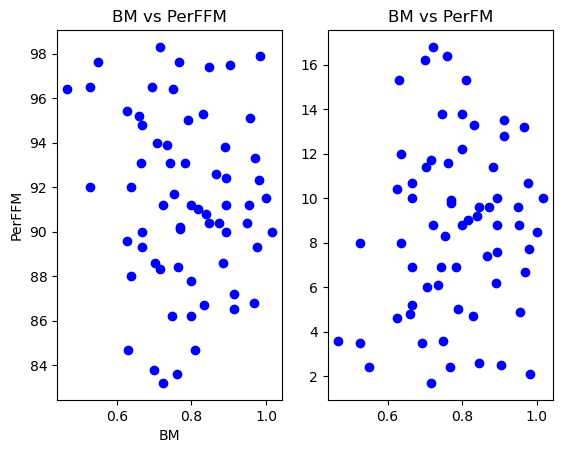

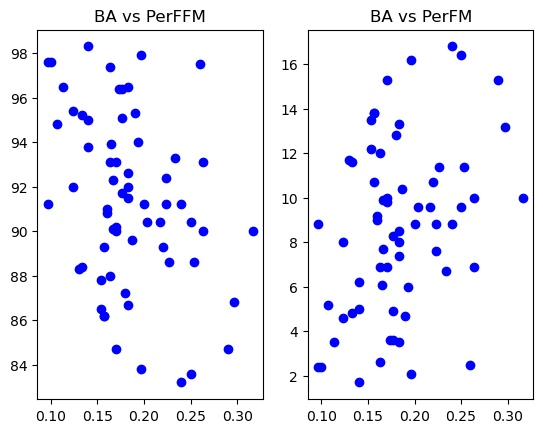

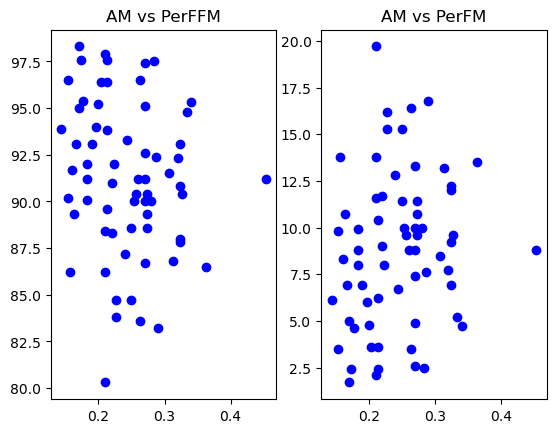

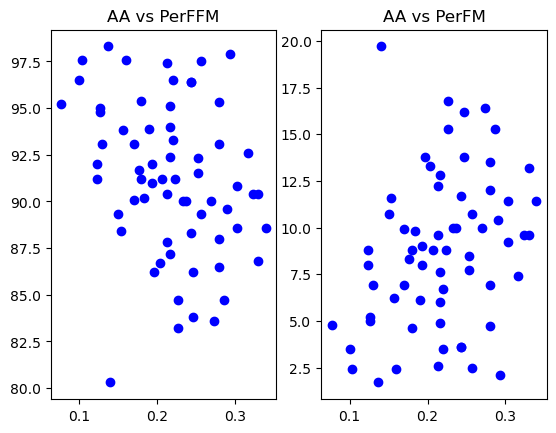

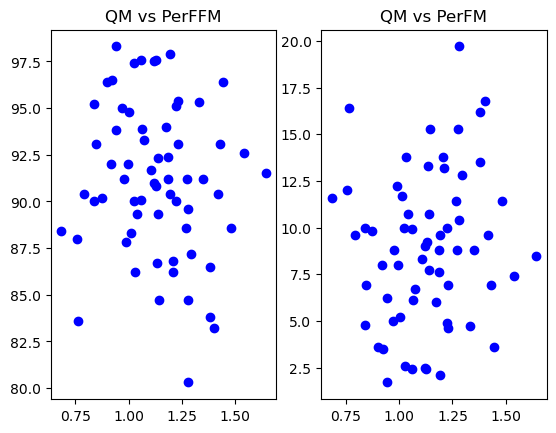

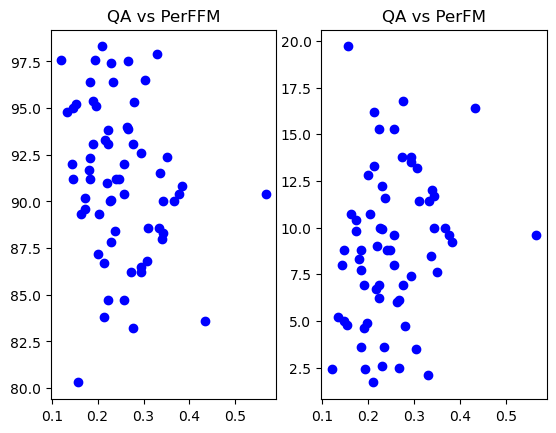

In [31]:
df = pd.concat([mm_avg, hp_avg], axis=1)
print(df)
plt.subplot(1, 2, 1)
plt.plot(df['BM'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('BM vs PerFFM')
plt.xlabel('BM')
plt.ylabel('PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['BM'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('BM vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['BA'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('BA vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['BA'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('BA vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['AM'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('AM vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['AM'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('AM vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['AA'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('AA vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['AA'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('AA vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['QM'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('QM vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['QM'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('QM vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['QA'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('QA vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['QA'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('QA vs PerFM')
plt.show()

In [32]:
matrix_3d_df = np.zeros((len(df), 2, 12))
for matrix_index in range(12):  
    idx = 1 + matrix_index // 2  
    matrix_3d_df[:, 0, matrix_index] = df.iloc[:, idx].values
    if matrix_index % 2 == 0:
        matrix_3d_df[:, 1, matrix_index] = df.iloc[:, 7].values
    else:
        matrix_3d_df[:, 1, matrix_index] = df.iloc[:, 8].values

In [33]:
def split_data(data,train_size=0.8,test_size=0.1,random_state=None): #diff  outcomes for each run
    train,temp=train_test_split(data,train_size=train_size,random_state=random_state)
    test_and_valid_size = 1.0-train_size
    test_ratio = test_size/test_and_valid_size
    test,valid = train_test_split(temp,test_size=test_ratio,random_state=random_state)
    return train, test, valid

In [75]:
rmse = torch.zeros(12, 1)
mse = torch.zeros(12, 1)
for index in range(12):
    train, test, valid = split_data(torch.tensor(matrix_3d_df[:,:,index], dtype=torch.float32))
    train = train[~torch.isnan(train).any(dim=1)]
    test = test[~torch.isnan(test).any(dim=1)]
    valid = valid[~torch.isnan(valid).any(dim=1)]

    train_x = train[:,0]
    train_y = train[:,1]
    test_x = test[:,0]
    test_y = test[:,1]

    #model
    class ExactGPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

        def forward(self, x):
            mean_x = self.mean_module(x)
            covar_x = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

    #initialize likelihood and model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model = ExactGPModel(train_x, train_y, likelihood)

    import os
    smoke_test = ('CI' in os.environ)
    training_iter = 2 if smoke_test else 50

    #optimal model hyperparameters with adam optimizer
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

    #marginal log likelihood loss
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -mll(output, train_y)
        loss.backward()
        print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
            i + 1, training_iter, loss.item(),
            model.covar_module.base_kernel.lengthscale.item(),
            model.likelihood.noise.item()
        ))
        optimizer.step()
    print("done with index ",index)

    # print("f_mean size:", f_mean.size())
    # print("test_y size:", test_y.size())
    # print("test_x size:", test_x.size())
    model.eval()
    likelihood.eval()

    preds = model(test_x)
    f_mean = preds.mean

    mse[index] = mse_loss(f_mean, test_y)
    rmse[index] = sqrt(mse[index])
    

Iter 1/50 - Loss: 12.045   lengthscale: 0.693   noise: 0.693
Iter 2/50 - Loss: 11.266   lengthscale: 0.644   noise: 0.744
Iter 3/50 - Loss: 10.563   lengthscale: 0.598   noise: 0.798
Iter 4/50 - Loss: 9.928   lengthscale: 0.554   noise: 0.854
Iter 5/50 - Loss: 9.355   lengthscale: 0.513   noise: 0.911
Iter 6/50 - Loss: 8.840   lengthscale: 0.474   noise: 0.970
Iter 7/50 - Loss: 8.377   lengthscale: 0.437   noise: 1.031
Iter 8/50 - Loss: 7.961   lengthscale: 0.403   noise: 1.092
Iter 9/50 - Loss: 7.588   lengthscale: 0.371   noise: 1.155
Iter 10/50 - Loss: 7.255   lengthscale: 0.342   noise: 1.218
Iter 11/50 - Loss: 6.958   lengthscale: 0.316   noise: 1.281
Iter 12/50 - Loss: 6.693   lengthscale: 0.294   noise: 1.345
Iter 13/50 - Loss: 6.457   lengthscale: 0.274   noise: 1.408
Iter 14/50 - Loss: 6.245   lengthscale: 0.259   noise: 1.472
Iter 15/50 - Loss: 6.053   lengthscale: 0.247   noise: 1.534
Iter 16/50 - Loss: 5.879   lengthscale: 0.238   noise: 1.596
Iter 17/50 - Loss: 5.720   len

Body Part  RMSE       MSE       
--------------------------------
BM PerFM   3.91       15.27     
BM PerFFM  3.60       12.93     
BA PerFM   4.07       16.58     
BA PerFFM  4.50       20.22     
AM PerFM   4.05       16.40     
AM PerFFM  5.94       35.24     
AA PerFM   3.51       12.29     
AA PerFFM  3.87       14.95     
QM PerFM   4.37       19.10     
QM PerFFM  4.45       19.79     
QA PerFM   4.04       16.33     
QA PerFFM  5.42       29.35     


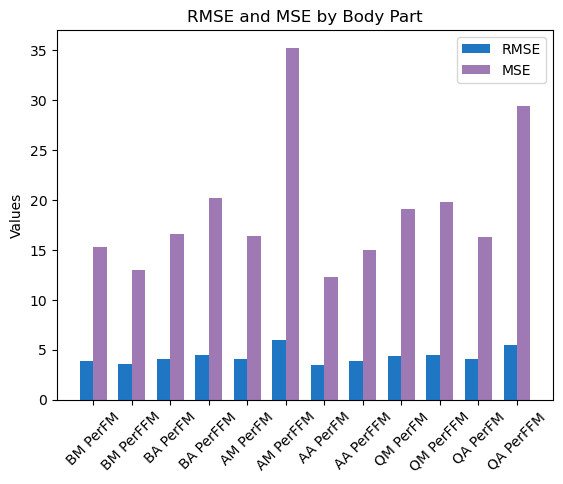

In [94]:
body_parts =["BM PerFM","BM PerFFM","BA PerFM","BA PerFFM","AM PerFM",
             "AM PerFFM","AA PerFM","AA PerFFM","QM PerFM","QM PerFFM",
             "QA PerFM","QA PerFFM"]
metrics = ["RMSE", "MSE"]

header = "{:<10} {:<10} {:<10}".format("Body Part", *metrics)
print(header)
print("-" * len(header))  

for index, part in enumerate(body_parts):
    rmse_value = rmse[index].item()  
    mse_value = mse[index].item()  
    row = "{:<10} {:<10.2f} {:<10.2f}".format(part, rmse_value, mse_value)
    print(row)

rmse_np = rmse.detach().cpu()
mae_np = mse.detach().cpu()

positions = torch.arange(len(body_parts))
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(positions - width/2, rmse_np.flatten(), width, label='RMSE',color ='#1f77c4')
rects2 = ax.bar(positions + width/2, mae_np.flatten(), width, label='MSE',color = '#9f79b4')

ax.set_ylabel('Values')
ax.set_title('RMSE and MSE by Body Part')
ax.set_xticks(positions)
ax.set_xticklabels(body_parts)
ax.legend()

plt.xticks(rotation=45)
plt.show()